In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Fill missing values
data["TotalCharges"] = data["TotalCharges"].fillna(
    data["TotalCharges"].median()
)

# Convert target
data["Churn"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

# Remove customer ID
data = data.drop(columns=["customerID"])

# Separate features and target
y = data["Churn"]
X = data.drop(columns=["Churn"])

# One-hot encode categorical features
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object"]).columns,
    drop_first=True,
    dtype=int
)

print("Dataset prepared successfully!")
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Dataset prepared successfully!
Feature shape: (7043, 30)
Target shape: (7043,)


C:\Users\aatik\AppData\Local\Temp\ipykernel_24168\2833290342.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns=X.select_dtypes(include=["object"]).columns,


In [3]:
# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

Training set: (5634, 30)
Validation set: (1409, 30)


In [4]:
# Compare Decision Tree models with different complexity levels

depths = [2, 5, 10, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_accuracy = accuracy_score(y_train, train_pred)
    val_accuracy = accuracy_score(y_val, val_pred)

    results.append({
        "max_depth": str(depth),
        "training_accuracy": train_accuracy,
        "validation_accuracy": val_accuracy
    })

comparison = pd.DataFrame(results)

print(comparison)

  max_depth  training_accuracy  validation_accuracy
0         2           0.791090             0.787083
1         5           0.801207             0.794180
2        10           0.872204             0.755855
3      None           0.998048             0.741661


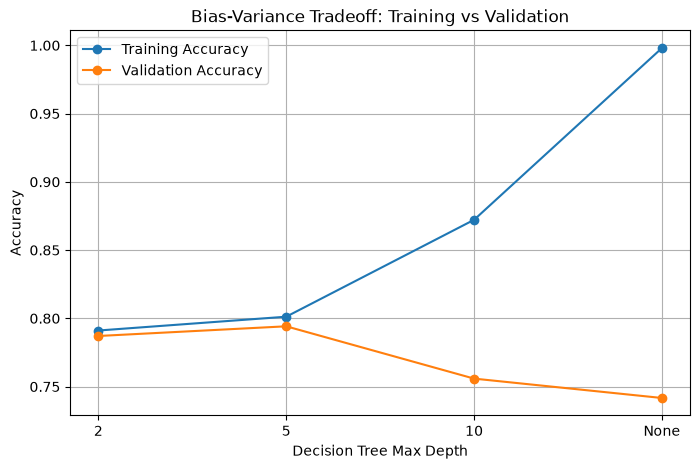

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    comparison["max_depth"],
    comparison["training_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    comparison["max_depth"],
    comparison["validation_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Decision Tree Max Depth")
plt.ylabel("Accuracy")
plt.title("Bias-Variance Tradeoff: Training vs Validation")
plt.legend()
plt.grid(True)

plt.savefig("bias_variance_complexity.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# Create a learning curve for the Decision Tree model

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# Calculate mean scores
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

print("Training scores:")
print(train_mean)

print("\nValidation scores:")
print(val_mean)

Training scores:
[0.85541741 0.8226106  0.80877986 0.80522217 0.80163294]

Validation scores:
[0.77069498 0.78006625 0.78986376 0.78943692 0.78688202]


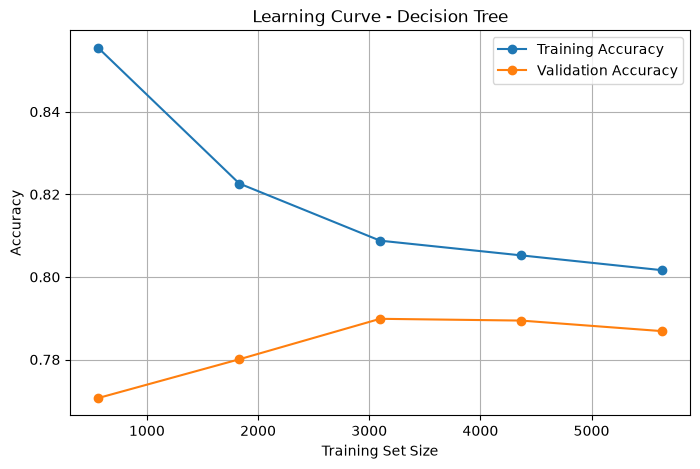

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Decision Tree")
plt.legend()
plt.grid(True)

plt.savefig("learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
learning_curve_data = pd.DataFrame({
    "training_size": train_sizes,
    "training_accuracy": train_mean,
    "validation_accuracy": val_mean
})

learning_curve_data.to_csv(
    "learning_curve_data.csv",
    index=False
)

comparison.to_csv(
    "bias_variance_comparison.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [9]:
# Generalization observations

print("Bias-Variance Observations")
print("-" * 30)

for _, row in comparison.iterrows():
    depth = row["max_depth"]
    train_acc = row["training_accuracy"]
    val_acc = row["validation_accuracy"]
    gap = train_acc - val_acc

    print(f"\nMax Depth: {depth}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Train-Validation Gap: {gap:.4f}")

    if train_acc < 0.75 and val_acc < 0.75:
        print("Observation: Possible underfitting.")
    elif gap > 0.10:
        print("Observation: Possible overfitting.")
    else:
        print("Observation: Training and validation performance are relatively close.")

Bias-Variance Observations
------------------------------

Max Depth: 2
Training Accuracy: 0.7911
Validation Accuracy: 0.7871
Train-Validation Gap: 0.0040
Observation: Training and validation performance are relatively close.

Max Depth: 5
Training Accuracy: 0.8012
Validation Accuracy: 0.7942
Train-Validation Gap: 0.0070
Observation: Training and validation performance are relatively close.

Max Depth: 10
Training Accuracy: 0.8722
Validation Accuracy: 0.7559
Train-Validation Gap: 0.1163
Observation: Possible overfitting.

Max Depth: None
Training Accuracy: 0.9980
Validation Accuracy: 0.7417
Train-Validation Gap: 0.2564
Observation: Possible overfitting.
